<a href="https://colab.research.google.com/github/sreent/machine-learning/blob/main/Code%20Walk%20Through/K-Nearest%20Neighbours.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [224]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

URL = "https://drive.google.com/file/d/1xvjAZZhAfTzKa6leFs50ovUKTp5rvXbw/view?usp=sharing"
FILE_PATH = "https://drive.google.com/uc?export=download&id=" + URL.split("/")[-2]

df = pd.read_csv(FILE_PATH)
df.head()

,X1,X2,X3,X4,Y
0,5.1,3.5,1.4,0.2,0.0
1,4.9,3.0,1.4,0.2,0.0
2,4.7,3.2,1.3,0.2,0.0
3,4.6,3.1,1.5,0.2,0.0
4,5.0,3.6,1.4,0.2,0.0


In [225]:
# feature names
features = list(df.columns)

# features or predictors
X = df[["X1", "X2", "X3", "X4"]].values

# target
y = df["Y"].astype(int).values

In [226]:
# number of dimensions
dimensions = X.shape[1]

# classes
classes = list(set(y))

In [227]:
# we have 3 classes in this case
classes

[0, 1, 2]

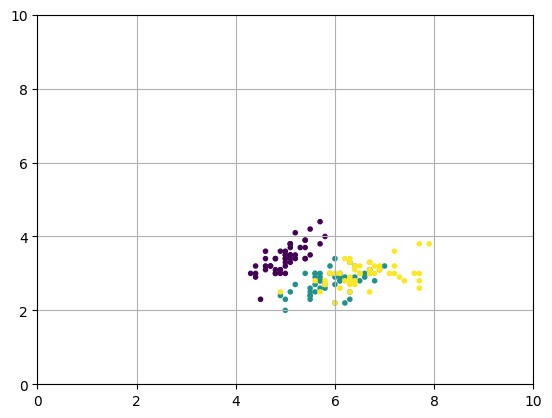

In [228]:
# the features are not the same scale. if we are to compute distances between data points, X1 will contribute to the distance more than X0
plt.scatter(X[:,0], X[:,1], marker='.', c=y/3)
plt.xlim([0, 10])
plt.ylim([0, 10])
plt.grid()
plt.show()

In [229]:
df.describe()

,X1,X2,X3,X4,Y
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [230]:
# compute mean values (one for each feature)
mus = X.mean(axis=0)
mus

array([5.84333333, 3.05733333, 3.758     , 1.19933333])

In [231]:
# compute standard deviation values (one for each feature)
sigmas = X.std(axis=0)
sigmas

array([0.82530129, 0.43441097, 1.75940407, 0.75969263])

In [232]:
# scaled features
Xs = (X - mus) / sigmas

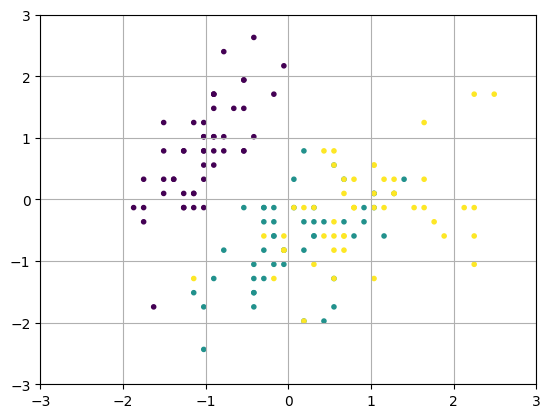

In [233]:
# replot - the variable ranges are now in the same scale.
plt.scatter(Xs[:,0], Xs[:,1], marker='.', c=y/3)
plt.xlim([-3, 3])
plt.ylim([-3, 3])
plt.grid()
plt.show()

In [234]:
# let check if they are all in the same scale
# notice the mean and std values.
# for means, they should be around 0
# for stds, they should be around 1
pd.DataFrame(data=Xs).describe()

,0,1,2,3
count,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02
mean,-4.736952e-16,-7.815970e-16,-4.263256e-16,-4.736952e-16
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00
min,-1.870024e+00,-2.433947e+00,-1.567576e+00,-1.447076e+00
25%,-9.006812e-01,-5.923730e-01,-1.226552e+00,-1.183812e+00
50%,-5.250608e-02,-1.319795e-01,3.364776e-01,1.325097e-01
75%,6.745011e-01,5.586108e-01,7.627583e-01,7.906707e-01
max,2.492019e+00,3.090775e+00,1.785832e+00,1.712096e+00


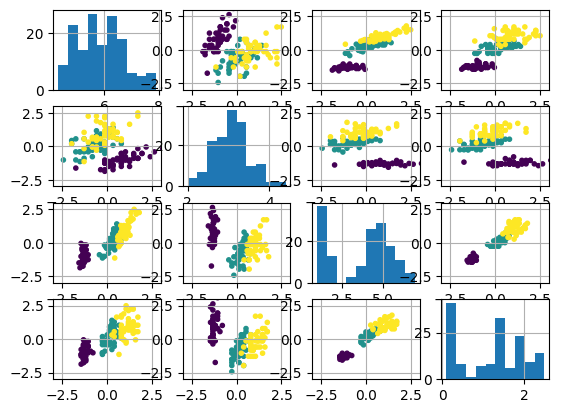

In [235]:
fig, axs = plt.subplots(dimensions, dimensions)
for i in range(dimensions) :
    for j in range(dimensions) :
        if i==j :
            axs[i, j].hist(X[:, i])
            axs[i,j].grid()
        else :
            axs[i, j].scatter(Xs[:,i], Xs[:,j], marker='.', c=y/3)
            axs[i,j].grid()
            axs[i,j].set_xlim([-3,3])
            axs[i,j].set_ylim([-3,3])

plt.show()

In [236]:
# if we can only have 2 features, X2 and X1 visibly seem to give clearer separations between the classes. The overlapping areas are less visible.

In [237]:
# euclidean distance
def euclidean_distance(x, y, norm=2) :
    return np.sum((x - y)**2, axis=1)**0.5

# manhattan distance
def manhattan_distance(x, y) :
    return np.sum(np.abs(x - y), axis=1)


In [238]:
x1 = np.array([[0,0], [0,1], [1,0], [1,1]])
x2 = np.array([0,0])

euclidean_distance(x1, x2)

array([0.        , 1.        , 1.        , 1.41421356])

In [239]:
x = np.array([-1, 1])

distances = euclidean_distance(Xs[:,0:2], x)

In [240]:
indices = np.argsort(distances)
indices

array([ 43,  40,   0,  17,  26,   7,  27,  39,   4,  37,  28,  11,  24,
        49,  23,  21,  31,  20,   6,  22,  36,  48,  10,  35,  19,  44,
        46,   2,  29,  47,  34,   9,  30,  42,   3,   5,  16,  18,  25,
         1,  45,  12,  85,  84,  70,  66,  88,  38,  95,  32,  13, 148,
        14,  64,   8,  61, 149, 136,  96, 100,  56, 138,  33,  91, 127,
       121,  99,  55, 115,  51,  78,  59, 114,  63, 137, 110,  94,  97,
        67,  82, 101, 142,  71,  73, 103, 124, 144, 116, 147, 104,  90,
       126,  74,  83,  79, 133,  75,  86,  65, 140,  15,  92, 143,  98,
       106, 132, 128,  77, 145,  58,  89, 120,  69, 123,  54, 113, 134,
       112, 139,  52, 141, 111,  50,  57,  81,  80, 109,  76, 125,  93,
        72, 146, 102,  53,  41, 129, 108, 107,  87, 119,  62, 130,  68,
       117, 105,  60, 135, 131, 122, 118])

In [241]:
distances[43], Xs[43,0:2]

(0.028957658316629845, array([-1.02184904,  1.01900435]))

In [242]:
distances[118], Xs[118,0:2]

(3.8437342629097344, array([ 2.24968346, -1.05276654]))

In [243]:
neighbours = 5

In [244]:
nearest_classes = y[indices[:neighbours]]
#nearest_classes

In [245]:
from collections import Counter

counter = Counter(nearest_classes)
counter

Counter({0: 5})

In [246]:
counter.most_common(1)[0][0]

0

In [247]:
def nearest_neighbours(X_train, y_train, X_test, k) :
    y_preds = []
    for i in range(X_test.shape[0]) :
        distances = euclidean_distance(X_train, X_test[i,:])
        # sort from nearest to furthest
        indices = np.argsort(distances)
        # retrieve classes of the k nearest data points
        nearest_classes = y_train[indices[:k]]
        # count number of points for each class
        counter = Counter(nearest_classes)

        # output (or predict) the class which has the most count
        y_pred = counter.most_common(1)[0][0]
        y_preds.append( y_pred )

    return np.array( y_preds )

In [248]:
X_test = np.array([[-1, 1], [1, 1]])
X_test

array([[-1,  1],
       [ 1,  1]])

In [249]:
nearest_neighbours(Xs[:,0:2], y, X_test, 5)

array([0, 2])

In [257]:
def train_test_split(X, y, train_size=0.8) :
    N = X.shape[0]
    indices = np.random.permutation(X.shape[0])
    splitting_index = int( np.ceil(train_size*N) )
    train_indices, test_indices = indices[:splitting_index], indices[splitting_index:]
    X_train, X_test = X[train_indices,:], X[test_indices,:]
    y_train, y_test = y[train_indices], y[test_indices]

    return X_train, X_test, y_train, y_test


In [292]:
X_train, X_test, y_train, y_test = train_test_split(X[:,0:2], y, 0.8)

In [293]:
X.shape, X_train.shape, X_test.shape

((150, 4), (120, 2), (30, 2))

In [294]:
y_pred = nearest_neighbours(X_train, y_train, X_test, 5)

In [295]:
y_pred.shape, y_test.shape

((30,), (30,))

In [296]:
def accuracy_score(y_true, y_pred) :
    return np.sum(y_true == y_pred) / len(y_true)

In [297]:
accuracy_score(y_test, y_pred)

0.7

In [298]:
# compute mean and standard deviation values (one for each feature)
mus = X_train.mean(axis=0)
sigmas = X_train.std(axis=0)

In [299]:
Xs_train = (X_train - mus)   / sigmas

In [300]:
Xs_test = (X_test - mus)   / sigmas

In [301]:
Xs_vtrain, Xs_val, y_vtrain, y_val = train_test_split(Xs_train, y_train, 0.8)

In [303]:
Xs_vtrain.shape, Xs_val.shape, y_vtrain.shape, y_val.shape

((96, 2), (24, 2), (96,), (24,))

In [307]:
y_pred = nearest_neighbours(Xs_vtrain, y_vtrain, Xs_val, 5)

In [311]:
accuracy_score(y_val, y_pred)

0.9166666666666666

In [312]:
val_acc = {}
for k in range(1, 76) :
    y_preds = nearest_neighbours(Xs_vtrain, y_vtrain, Xs_val, k)

    val_acc[k] = accuracy_score(y_val, y_preds)

print(val_acc)

{1: 0.875, 2: 0.875, 3: 0.9166666666666666, 4: 0.9166666666666666, 5: 0.9166666666666666, 6: 0.9166666666666666, 7: 0.875, 8: 0.875, 9: 0.875, 10: 0.8333333333333334, 11: 0.8333333333333334, 12: 0.8333333333333334, 13: 0.8333333333333334, 14: 0.875, 15: 0.8333333333333334, 16: 0.8333333333333334, 17: 0.875, 18: 0.875, 19: 0.875, 20: 0.875, 21: 0.875, 22: 0.9166666666666666, 23: 0.9166666666666666, 24: 0.875, 25: 0.9166666666666666, 26: 0.9166666666666666, 27: 0.9166666666666666, 28: 0.9166666666666666, 29: 0.9166666666666666, 30: 0.8333333333333334, 31: 0.875, 32: 0.875, 33: 0.8333333333333334, 34: 0.875, 35: 0.875, 36: 0.875, 37: 0.875, 38: 0.875, 39: 0.875, 40: 0.875, 41: 0.8333333333333334, 42: 0.875, 43: 0.875, 44: 0.875, 45: 0.875, 46: 0.875, 47: 0.875, 48: 0.875, 49: 0.875, 50: 0.875, 51: 0.8333333333333334, 52: 0.875, 53: 0.8333333333333334, 54: 0.875, 55: 0.8333333333333334, 56: 0.8333333333333334, 57: 0.8333333333333334, 58: 0.8333333333333334, 59: 0.8333333333333334, 60: 0.83

In [314]:
train_acc = {}
for k in range(1, 76) :
    y_preds = nearest_neighbours(Xs_vtrain, y_vtrain, Xs_vtrain, k)

    train_acc[k] = accuracy_score(y_vtrain, y_preds)

print(train_acc)

{1: 0.9166666666666666, 2: 0.9166666666666666, 3: 0.8020833333333334, 4: 0.8541666666666666, 5: 0.7708333333333334, 6: 0.8229166666666666, 7: 0.7604166666666666, 8: 0.8125, 9: 0.8020833333333334, 10: 0.8333333333333334, 11: 0.7916666666666666, 12: 0.8020833333333334, 13: 0.7916666666666666, 14: 0.7916666666666666, 15: 0.78125, 16: 0.7916666666666666, 17: 0.7708333333333334, 18: 0.8020833333333334, 19: 0.7604166666666666, 20: 0.7708333333333334, 21: 0.7604166666666666, 22: 0.7916666666666666, 23: 0.7708333333333334, 24: 0.8125, 25: 0.7916666666666666, 26: 0.8020833333333334, 27: 0.7916666666666666, 28: 0.78125, 29: 0.7708333333333334, 30: 0.7916666666666666, 31: 0.7708333333333334, 32: 0.7916666666666666, 33: 0.78125, 34: 0.8020833333333334, 35: 0.78125, 36: 0.7916666666666666, 37: 0.78125, 38: 0.7708333333333334, 39: 0.7604166666666666, 40: 0.7708333333333334, 41: 0.7708333333333334, 42: 0.7708333333333334, 43: 0.7604166666666666, 44: 0.7604166666666666, 45: 0.7604166666666666, 46: 0.7

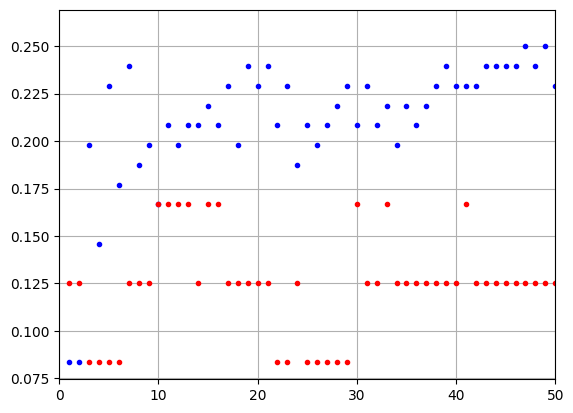

In [315]:
train_error = 1-np.array(list(train_acc.values()))
val_error = 1-np.array(list(val_acc.values()))

plt.plot(list(train_acc.keys()), train_error, 'b.')
plt.plot(list(val_acc.keys()), val_error, 'r.')
plt.xlim(0,50)
plt.grid()
plt.show()

In [322]:
y_pred = nearest_neighbours(Xs_vtrain, y_vtrain, Xs_val, 5)
accuracy_score(y_val, y_pred)

0.9166666666666666

In [323]:
y_pred = nearest_neighbours(Xs_train, y_train, Xs_test, 5)
accuracy_score(y_test, y_pred)

0.7333333333333333

In [327]:
def confusion_matrix(y_true, y_pred, classes) :
    n = len(classes)
    matrix = np.zeros((n,n))
    for i, j in zip(y_true, y_pred) :
        matrix[i,j] += 1

    return matrix

In [328]:
confusion_matrix(y_test, y_pred, classes)

array([[ 8.,  1.,  0.],
       [ 0., 10.,  4.],
       [ 0.,  3.,  4.]])

In [331]:
(8+10+4) / (8+1+10+4+3+4)

0.7333333333333333

In [223]:
y_pred == y_test

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True])

In [152]:
y_test

array([0, 2, 1, 0, 2, 0, 2, 2, 2, 0, 0, 2, 1, 0, 1, 0, 0, 2, 0, 2, 1, 0,
       2, 1, 2, 1, 1, 0, 2, 2])